<a href="https://colab.research.google.com/github/Namzey/A-Signal-Processing-Approach-to-Financial-Time-Series-Using-FFT/blob/main/Code_G03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd
print("pandas working")

pandas working


In [ ]:
!pip install numpy matplotlib yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("all imports working")

all imports working


In [ ]:
import yfinance as yf

tickers = ["AAPL", "MSFT", "AMZN"]

data = yf.download(tickers, start="2020-01-01", end="2024-01-01")
#checking what kind of data is yfinance returning
print(data.columns)

/tmp/ipykernel_879/1038970789.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  3 of 3 completed

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'MSFT'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'MSFT'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'MSFT'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open', 'MSFT'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [ ]:
prices = data["Close"]

print(prices.head())

Ticker           AAPL       AMZN        MSFT
Date                                        
2020-01-02  72.400513  94.900497  152.158401
2020-01-03  71.696640  93.748497  150.263779
2020-01-06  72.267921  95.143997  150.652161
2020-01-07  71.928062  95.343002  149.278549
2020-01-08  73.085106  94.598503  151.656311


In [ ]:
import os
os.makedirs("../data", exist_ok=True)
prices.to_csv("../data/prices.csv") #saving the data to a csv file for later use
#takes control to sas project folder then /data/prices excecuted

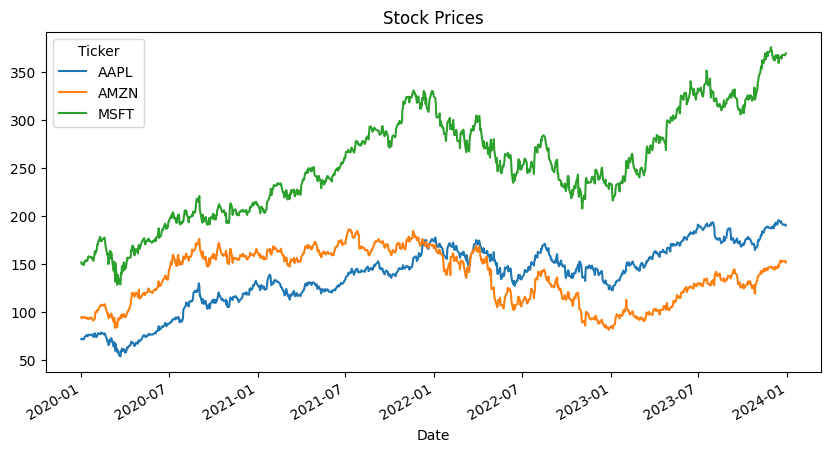

In [ ]:
import matplotlib.pyplot as plt

prices.plot(figsize=(10,5))
plt.title("Stock Prices")
plt.show()

In [ ]:
import pandas as pd

prices = pd.read_csv("../data/prices.csv", index_col=0)

print(prices.head()) #confiming that we can read the data back in correctly

                 AAPL       AMZN        MSFT
Date                                        
2020-01-02  72.400513  94.900497  152.158401
2020-01-03  71.696640  93.748497  150.263779
2020-01-06  72.267921  95.143997  150.652161
2020-01-07  71.928062  95.343002  149.278549
2020-01-08  73.085106  94.598503  151.656311


In [ ]:
corr = prices.corr()

print(corr)

          AAPL      AMZN      MSFT
AAPL  1.000000  0.172681  0.939222
AMZN  0.172681  1.000000  0.274980
MSFT  0.939222  0.274980  1.000000


In [ ]:
pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        value = corr.iloc[i, j]

        if value > 0.8:
            pairs.append((corr.columns[i], corr.columns[j], value))

print(pairs)

[('MSFT', 'AAPL', np.float64(0.9392217895055703))]


In [ ]:
#NOW WE KNOW WHICH STOCKS ARE HIGHLY CORRELATED, BUT CAN WE TRADE THEM PROFITABLY? LETS CHECK WHETHER THE DISTANCE STAYS STABLE OVER TIME
#PICKING ONE PAIR FROM THE LIST OF HIGHLY CORRELATED STOCKS
stock1 = "MSFT"
stock2 = "AAPL"

In [ ]:
# Select individual price series for each stock
S1 = prices[stock1]   # MSFT prices over time , gives time series (signal) of MSFT
S2 = prices[stock2]   # AAPL prices over time

# Compute spread (difference between the two)
#spread = S1 - S2

#This spread is:
 #Your core signal
 #This is what:
#SAS will process
#trading decisions will use



# Print first few values to verify
#print(spread.head())

In [ ]:
import numpy as np

# compute hedge ratio beta
beta = np.polyfit(S2, S1, 1)[0]

print("Beta:", beta)

# correct spread
spread = S1 - beta * S2

# check
print(spread.head())
print(beta)

Beta: 1.5432483433309687
Date
2020-01-02    40.426430
2020-01-03    39.618058
2020-01-06    39.124811
2020-01-07    38.275686
2020-01-08    38.867842
dtype: float64
1.5432483433309687


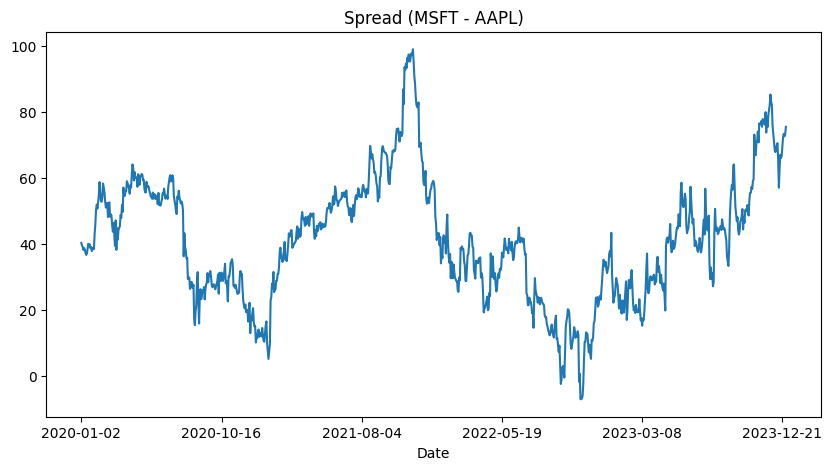

In [ ]:
import matplotlib.pyplot as plt

# Plot the spread signal
spread.plot(figsize=(10,5))

# Add title for clarity
plt.title("Spread (MSFT - AAPL)")

# Show the graph
plt.show()

In [ ]:
# Apply moving average filter (window = 20 days)
filtered_spread = spread.rolling(window=20).mean()

# Print first few values
print(filtered_spread.head(25))

Date
2020-01-02          NaN
2020-01-03          NaN
2020-01-06          NaN
2020-01-07          NaN
2020-01-08          NaN
2020-01-09          NaN
2020-01-10          NaN
2020-01-13          NaN
2020-01-14          NaN
2020-01-15          NaN
2020-01-16          NaN
2020-01-17          NaN
2020-01-21          NaN
2020-01-22          NaN
2020-01-23          NaN
2020-01-24          NaN
2020-01-27          NaN
2020-01-28          NaN
2020-01-29          NaN
2020-01-30    38.984879
2020-01-31    39.269686
2020-02-03    39.807292
2020-02-04    40.451904
2020-02-05    41.080189
2020-02-06    41.785604
dtype: float64


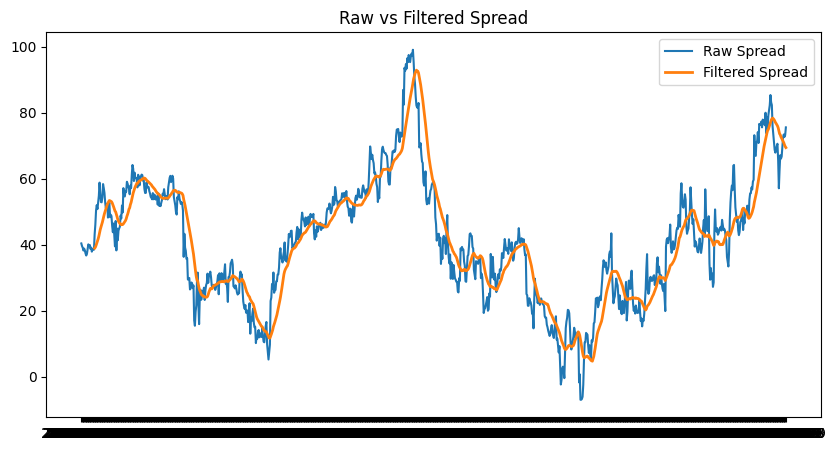

In [ ]:
import matplotlib.pyplot as plt

# Plot both signals
plt.figure(figsize=(10,5))

plt.plot(spread, label="Raw Spread")
plt.plot(filtered_spread, label="Filtered Spread", linewidth=2)

plt.legend()
plt.title("Raw vs Filtered Spread")

plt.show()

In [ ]:
# Compute mean of spread
mean = spread.mean()

# Compute standard deviation
std = spread.std()

# Normalize (Z-score)
zscore = (spread - mean) / std

# Print first few values
print(zscore.head())

Date
2020-01-02   -0.045271
2020-01-03   -0.088231
2020-01-06   -0.114443
2020-01-07   -0.159568
2020-01-08   -0.128099
dtype: float64


In [ ]:

# Define rolling window
window = 20

# Compute rolling mean (average of past 20 days)
rolling_mean = spread.rolling(window=window).mean()

# Compute rolling standard deviation (volatility of past 20 days)
rolling_std = spread.rolling(window=window).std()

# Compute Z-score (normalized spread)
# This tells us how far spread is from its recent average
zscore = (spread - rolling_mean) / rolling_std

# Print first few values to check
print(zscore.head(25))

Date
2020-01-02         NaN
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
2020-01-09         NaN
2020-01-10         NaN
2020-01-13         NaN
2020-01-14         NaN
2020-01-15         NaN
2020-01-16         NaN
2020-01-17         NaN
2020-01-21         NaN
2020-01-22         NaN
2020-01-23         NaN
2020-01-24         NaN
2020-01-27         NaN
2020-01-28         NaN
2020-01-29         NaN
2020-01-30    3.058443
2020-01-31    3.273413
2020-02-03    3.250898
2020-02-04    2.730353
2020-02-05    2.037207
2020-02-06    2.056002
dtype: float64


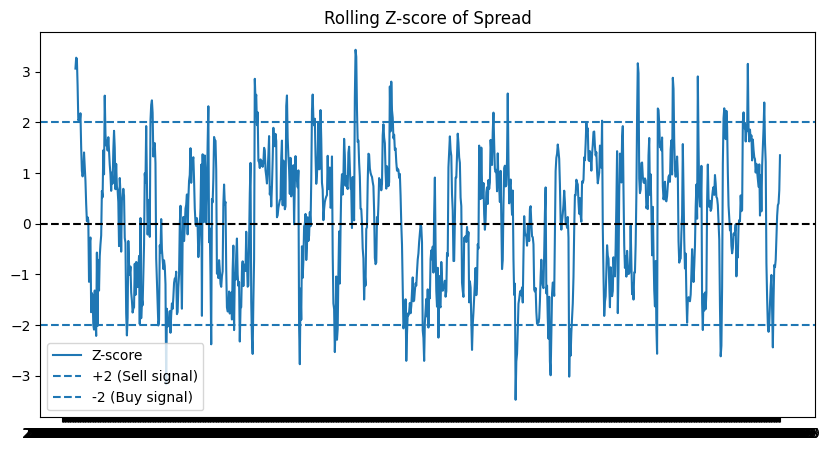

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot Z-score
plt.plot(zscore, label="Z-score")

# Add threshold lines (important for trading)
plt.axhline(2, linestyle='--', label="+2 (Sell signal)")
plt.axhline(-2, linestyle='--', label="-2 (Buy signal)")
plt.axhline(0, linestyle='--', color='black')

# Add labels
plt.title("Rolling Z-score of Spread")
plt.legend()

plt.show()

In [ ]:
!pip install statsmodels
import statsmodels.api as sm

In [ ]:


# Import cointegration test function
from statsmodels.tsa.stattools import coint

# Perform cointegration test between the two price series
score, pvalue, _ = coint(S1, S2)

# Print result
print("Cointegration p-value:", pvalue)

Cointegration p-value: 0.3603307389238855


In [ ]:


# Create empty list to store positions
positions = []

# Loop through z-score values
for z in zscore:

    # If spread is too high → short spread
    if z > 2:
        positions.append(-1)

    # If spread is too low → long spread
    elif z < -2:
        positions.append(1)

    # Otherwise → no trade
    else:
        positions.append(0)

# Convert to pandas series (important for alignment)
positions = pd.Series(positions, index=spread.index)

# Print first few values
print(positions.head())

Date
2020-01-02    0
2020-01-03    0
2020-01-06    0
2020-01-07    0
2020-01-08    0
dtype: int64


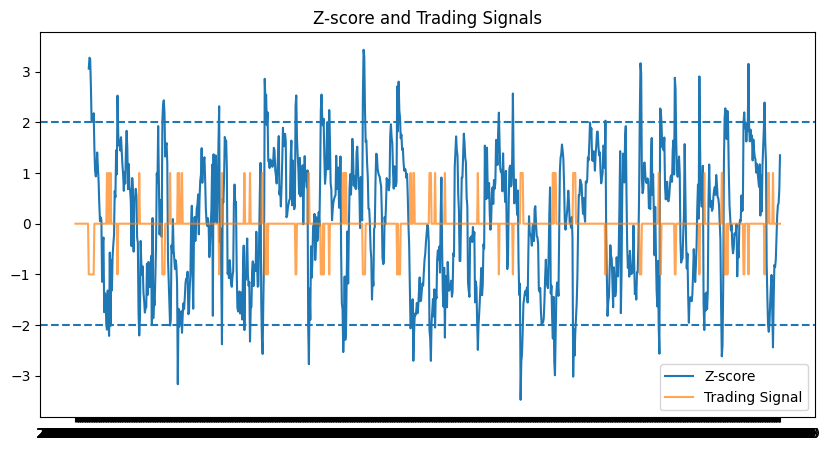

In [ ]:

plt.figure(figsize=(10,5))

plt.plot(zscore, label="Z-score")
plt.plot(positions, label="Trading Signal", alpha=0.7)

plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

plt.title("Z-score and Trading Signals")
plt.legend()

plt.show()

In [ ]:

# Calculate daily returns of both stocks
returns1 = S1.pct_change()
returns2 = S2.pct_change()

# Strategy returns:
# position × (relative movement of two stocks)
strategy_returns = positions.shift(1) * (returns1 - beta * returns2)

# Remove NaN values
strategy_returns = strategy_returns.dropna()

# Compute cumulative returns (growth of $1)
cumulative_returns = (1 + strategy_returns).cumprod()

# Print first few values
print(cumulative_returns.head())

Date
2020-01-03    1.0
2020-01-06    1.0
2020-01-07    1.0
2020-01-08    1.0
2020-01-09    1.0
dtype: float64


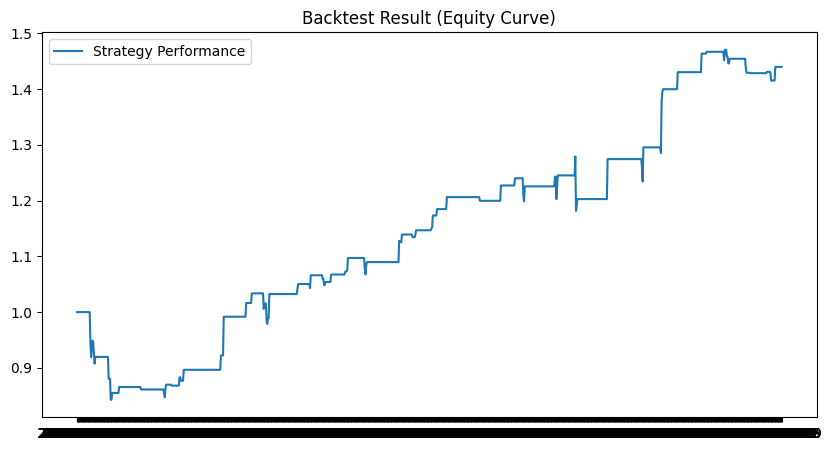

In [ ]:

plt.figure(figsize=(10,5))

plt.plot(cumulative_returns, label="Strategy Performance")

plt.title("Backtest Result (Equity Curve)")
plt.legend()

plt.show()

In [ ]:


import numpy as np

# Compute returns (remove NaN)
returns = S1.pct_change().dropna()

# Apply Fast Fourier Transform
fft_vals = np.fft.fft(returns)

# Compute power spectrum (energy at each frequency)
power = np.abs(fft_vals) ** 2

# Print first few values
print(power[:10])

[1.21022091 0.34845101 0.1979009  0.23730744 0.07305449 0.06756876
 0.25842243 0.12271539 0.20545814 0.08957439]


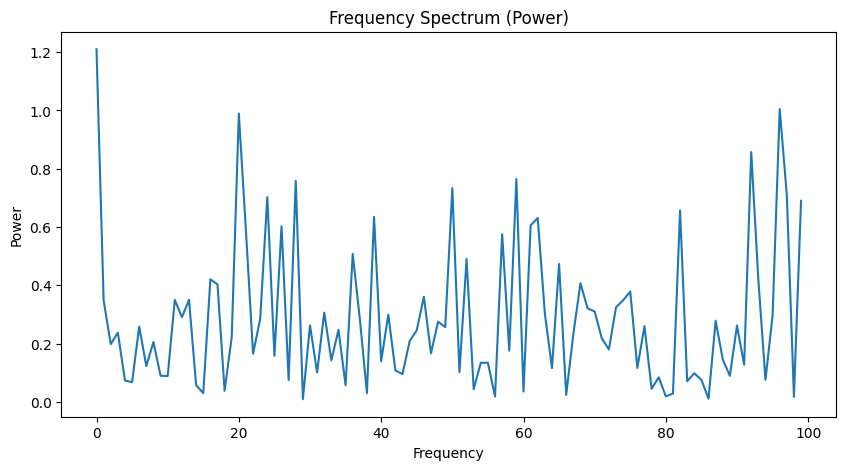

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot only first half (useful part)
plt.plot(power[:100])

plt.title("Frequency Spectrum (Power)")
plt.xlabel("Frequency")
plt.ylabel("Power")

plt.show()

In [ ]:
# ======================================
# STEP: Measure high-frequency energy
# ======================================

# Define cutoff (can be tuned)
cutoff = 50

# Sum high-frequency components
high_freq_energy = np.sum(power[cutoff:])

print("High frequency energy:", high_freq_energy)

High frequency energy: 413.0310668716895


In [ ]:


threshold = np.percentile(power, 90)

if high_freq_energy > threshold:
    print("Market is VOLATILE → Avoid trading")
else:
    print("Market is STABLE → Trading allowed")

Market is VOLATILE → Avoid trading


In [ ]:

# STEP: Rolling FFT-based volatility signal


window = 128  # number of points per FFT window

hf_energy_series = []

# loop over time to compute rolling FFT energy
for i in range(len(returns)):

    if i < window:
        hf_energy_series.append(np.nan)
    else:
        segment = returns.iloc[i-window:i]

        fft_vals = np.fft.fft(segment)
        power = np.abs(fft_vals) ** 2

        # high-frequency part (upper half)
        hf_energy = np.sum(power[len(power)//2:])

        hf_energy_series.append(hf_energy)

# convert to pandas series
hf_energy_series = pd.Series(hf_energy_series, index=returns.index)

print(hf_energy_series.head(150))

Date
2020-01-03         NaN
2020-01-06         NaN
2020-01-07         NaN
2020-01-08         NaN
2020-01-09         NaN
                ...   
2020-07-31    9.669070
2020-08-03    9.658270
2020-08-04    9.801986
2020-08-05    9.802547
2020-08-06    9.771907
Length: 150, dtype: float64


In [ ]:

# STEP: Define volatility threshold


threshold = hf_energy_series.quantile(0.8)

print("Volatility threshold:", threshold)

Volatility threshold: 4.036991721460063


In [ ]:

# STEP: Create regime filter


# True = safe to trade, False = avoid
trade_filter = hf_energy_series < threshold

print(trade_filter.head())

Date
2020-01-03    False
2020-01-06    False
2020-01-07    False
2020-01-08    False
2020-01-09    False
dtype: bool


In [ ]:

# STEP: Filter trading signals


filtered_positions = positions.copy()

# align indices (important)
filtered_positions = filtered_positions.loc[trade_filter.index]

# apply filter
filtered_positions[~trade_filter] = 0

print(filtered_positions.head())

Date
2020-01-03    0
2020-01-06    0
2020-01-07    0
2020-01-08    0
2020-01-09    0
dtype: int64


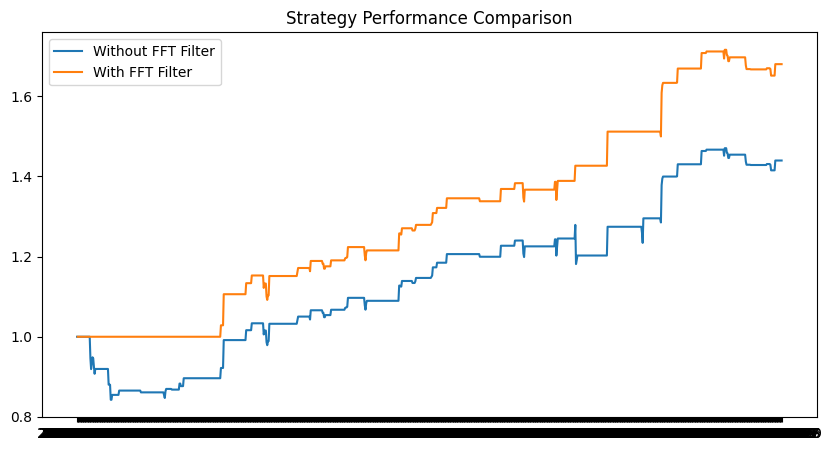

In [ ]:

# STEP: Backtest with filter


strategy_returns_filtered = filtered_positions.shift(1) * (returns1 - beta * returns2)

strategy_returns_filtered = strategy_returns_filtered.dropna()

cum_returns_filtered = (1 + strategy_returns_filtered).cumprod()

# plot comparison
plt.figure(figsize=(10,5))

plt.plot(cumulative_returns, label="Without FFT Filter")
plt.plot(cum_returns_filtered, label="With FFT Filter")

plt.title("Strategy Performance Comparison")
plt.legend()

plt.show()

/tmp/ipykernel_879/787580911.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(['MSFT', 'AAPL'], start='2015-01-01', end='2020-01-01', progress=False)['Close']


Baseline Return: -14.56%
FFT Return:      -16.19%


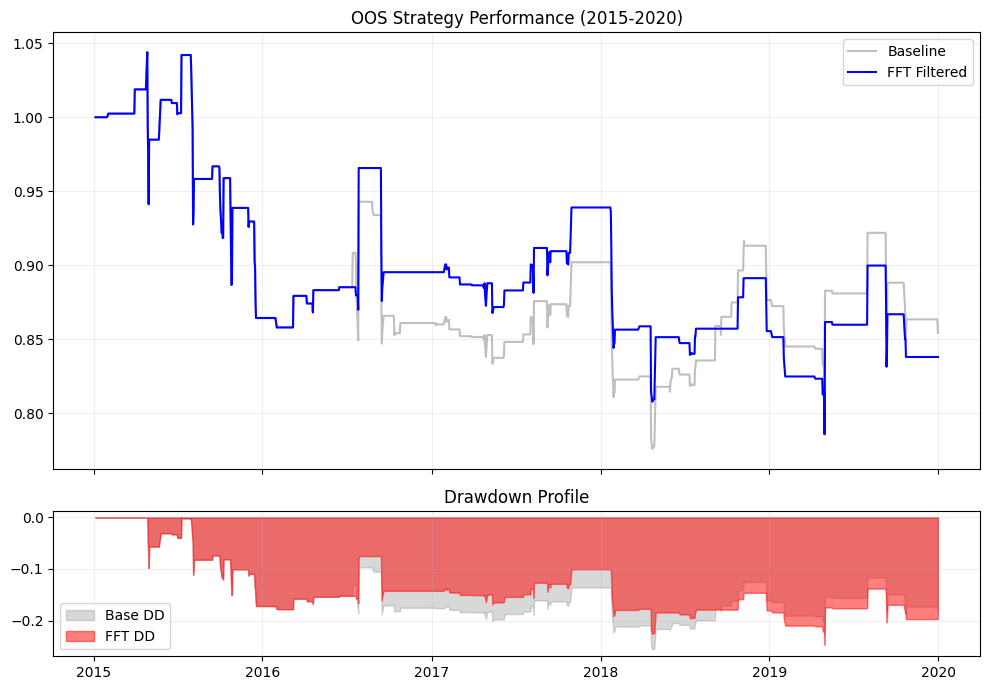

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fetch data and align
data = yf.download(['MSFT', 'AAPL'], start='2015-01-01', end='2020-01-01', progress=False)['Close']
msft, aapl = data['MSFT'].align(data['AAPL'], join='inner')

# Calculate spread and dynamic daily returns
beta = 1.54  # Assuming beta was imported from training module
spread = msft - (beta * aapl)
daily_rets = msft.pct_change() - (beta * aapl.pct_change())

# Z-Score signal generation
roll_mean = spread.rolling(20).mean()
roll_std = spread.rolling(20).std()
z_score = (spread - roll_mean) / roll_std

raw_pos = pd.Series(0, index=spread.index)
raw_pos[z_score > 2] = -1
raw_pos[z_score < -2] = 1

# FFT Volatility Filter (using dollar differences, not pct_change, to avoid zero-division)
spread_diff = spread.diff().dropna()
window = 128
hf_ratio = pd.Series(index=spread_diff.index, dtype=float)

for i in range(window, len(spread_diff)):
    power = np.abs(np.fft.fft(spread_diff.iloc[i-window:i]))**2
    hf_ratio.iloc[i] = np.sum(power[len(power)//2:]) / np.sum(power)

# 252-day rolling threshold
rolling_thresh = hf_ratio.rolling(252).quantile(0.8)

# Apply Filter (Halt trading if noisy, UNLESS z-score is an extreme >2.5 outlier)
raw_pos = raw_pos.reindex(daily_rets.index).fillna(0)
filtered_pos = raw_pos.copy()

mask = (hf_ratio > rolling_thresh) & (z_score.abs() < 2.5)
filtered_pos[mask] = 0

# Vectorized performance calculation
base_pnl = (raw_pos.shift(1) * daily_rets).dropna()
fft_pnl = (filtered_pos.shift(1) * daily_rets).dropna()

cum_base = (1 + base_pnl).cumprod()
cum_fft = (1 + fft_pnl).cumprod()

def calc_drawdown(equity_curve):
    peak = equity_curve.cummax()
    return (equity_curve - peak) / peak

# Output formatting
print(f"Baseline Return: {(cum_base.iloc[-1] - 1) * 100:.2f}%")
print(f"FFT Return:      {(cum_fft.iloc[-1] - 1) * 100:.2f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(cum_base, label="Baseline", alpha=0.5, color='gray')
ax1.plot(cum_fft, label="FFT Filtered", color='blue')
ax1.set_title("OOS Strategy Performance (2015-2020)")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.fill_between(cum_base.index, calc_drawdown(cum_base), color='gray', alpha=0.3, label="Base DD")
ax2.fill_between(cum_fft.index, calc_drawdown(cum_fft), color='red', alpha=0.5, label="FFT DD")
ax2.set_title("Drawdown Profile")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()